In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import os
import imageio

#%matplotlib qt   # commented out so that the images can be seen in the notebook


In [3]:
root_directory = "HippocampalMRISlices"
patient_num = 1

# Get the list patient folders
patient_folders = sorted(os.listdir(root_directory))

# Get the single patient folder you are looking for 
directory = os.path.join(root_directory, patient_folders[patient_num])

# All the dicoms for a particular folder
dicom_names = os.listdir(directory)


In [4]:
def get_vol_data(patient_num):  
    """
    function to get data from dicom file
    """
    
    directory = os.path.join(root_directory, patient_folders[patient_num])
    
    # index doesn't seem to do anything here,
    # howver image IO doesn't work with just the folder as input 
    index = 0 
    entry = os.listdir(directory)[index]
    entry_path = os.path.join(directory, entry)
    
    # Vol read here seems to be looking in the entire directory path
    # and loading the data that way, if there was only one file 
    # there this would not extract the whole volume 
    # While this does seem to work, it seems to stuggle to get the 
    # order of the slices correct
    vol_data = imageio.volread(entry_path)  # read dicom file
    
    return vol_data  # return dicom data


In [5]:
def directional_slices(vol, number_of_slice, slice_type):
    '''returns the information of the input vol for 
    the specified slice, to be plotted
    slice_type are defined as 'axial', 'coronal', and 'saggital' 
    number_of_slice defines the specific slice to be returned
    '''

    if slice_type == 'axial':
        return vol[number_of_slice,:,:]
    elif slice_type == 'coronal':
        return vol[:,number_of_slice,:]
    elif slice_type == 'saggital':
        return vol[:,:,number_of_slice]
    else:
        raise ValueError("Please choose from 'axial', 'coronal', or 'saggital', and a slice number must be between 0 and 255")

In [6]:
# Getting the voldata every time is slowing you down, 
# so just do it once 
vol = get_vol_data(3)
index = 50
axial_slice = directional_slices(vol, index, 'axial')
saggital_slice = directional_slices(vol, index, 'saggital')
coronal_slice = directional_slices(vol, index, 'coronal')

Reading DICOM (examining files): 1/333 files (0.3272/333 files (81.7  DICOM file has no SamplesPerPixel (perhaps this is a report?)
Reading DICOM (examining files): 272/333 files (81.7%333/333 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 332/332  (100.0%)


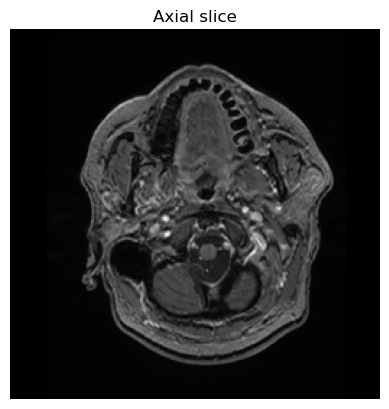

In [7]:
#####         AXIAL         #####
plt.close('all')
plt.figure()
plt.imshow(axial_slice, cmap='gray')
plt.title('Axial slice')
plt.axis('off')
plt.show()

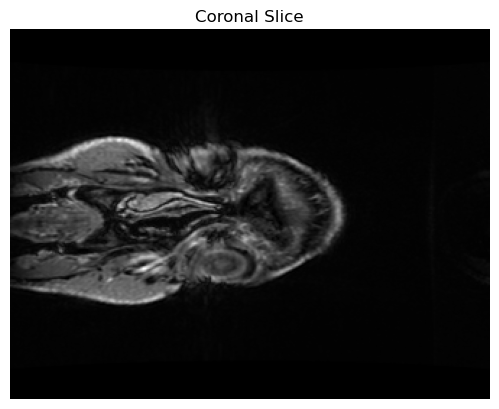

In [8]:
#####    CORONAL    #####
plt.figure()
plt.imshow(coronal_slice.T, cmap='gray') # print pixel data of dicom file
plt.title('Coronal Slice')
plt.axis('off')
plt.show()

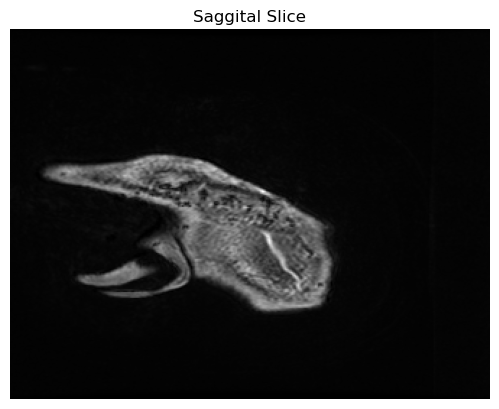

In [9]:
#####    SAGITTAL    #####
plt.figure()
plt.imshow(saggital_slice.T, cmap='gray') # print pixel data of dicom file
plt.title('Saggital Slice')
plt.axis('off')
plt.show()

### With Feedback - Using the data in all the files to generate the coronal and sagittal slices

In [11]:
def list_of_pixel_data(directory):
    dicoms = []
    for index in range(len(os.listdir(directory))):
        if 'MR' in str(os.listdir(directory)[index]):
            entry = os.listdir(directory)[index]
            ds = pydicom.dcmread(os.path.join(directory, entry))
            dicoms.append(ds)
    
    dicoms = sorted(dicoms,key=lambda x: float(x.SliceLocation))
    all_pixel_data = [ds.pixel_array for ds in dicoms]

    return all_pixel_data

Pat1_directory = r'HippocampalMRISlices\01' #Pat1 meaning patient 1
Pat1_pixel_data = np.array(list_of_pixel_data(Pat1_directory))


In [12]:
Pat1_pixel_data.shape

(276, 256, 256)

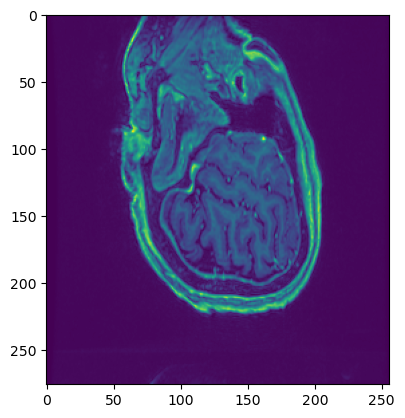

In [13]:
plt.figure()
plt.imshow(Pat1_pixel_data[:,:,70])

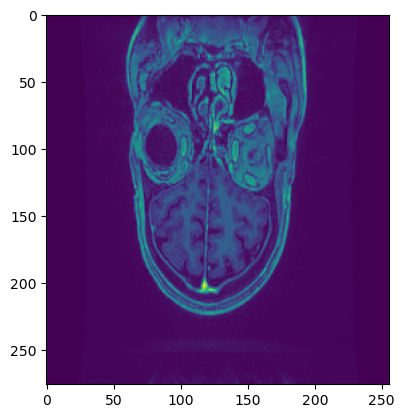

In [14]:
plt.figure()
plt.imshow(Pat1_pixel_data[:,70,:])

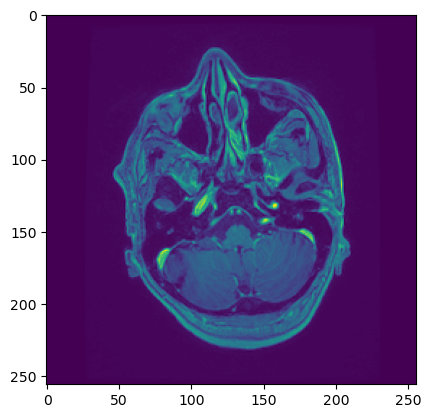

In [15]:
## axial
plt.figure()
plt.imshow(Pat1_pixel_data[70,:,:])